In [1]:
using Plots, DataFrames, CSV, GLM, Statistics, LinearAlgebra, Distributions

n=10

x = sort((rand(-10:100, n)))
y = 5/9 .* (x .-32)


begin	
	plot(x,y, m=:c, mc=:red,legend=false)
	xlabel!("F")
	annotate!(-4,16,text("°C",11))
	# plot!( x, (x.-30)./2) Dave's cool approximation
end
data = DataFrame(F = x, C=y)

begin
	data2 = DataFrame([x  y], :auto) # convert Matrix to DataFrame
    rename!(data2,["F","C"]) # add column labels
end
Matrix(data2)

CSV.write("testCSV", data)
data_again = CSV.read("testCSV", DataFrame ) 
data_again[:,"F" ] 
data_again[:,1]

noise = 7.5
model = lm(@formula(C ~ F), noisy_data)
b, m = coef(model)
begin
    noisy_data = copy(data)
    noisy_data[:, "C"] .+= noise * randn(n)
    yy = noisy_data[:,"C"]
    noisy_data
end


begin
	
	scatter(x, yy,m=:c,mc=:red, label="noisy data", ylims=(-40, 40))
	for i=1 : length(data[:,2])
		plot!([x[i],x[i]], [m*x[i]+b,yy[i]], color=:gray, ls=:dash, label=false)
	end
	xlabel!("°F")
	annotate!(-15,16,text("°C",11))
	plot!(x, m.*x .+ b,  color=:blue, label="best fit line")
	plot!(x,y,alpha=.5, color=:red, label="theory") # theoretical 
	plot!(legend=:top)
end







UndefVarError: UndefVarError: `noisy_data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
b, m = [one.(x) x] \ yy
function linear_regression(x,y)  
	n = length(x)
	x0  = x.-mean(x)
	y0 = y.-mean(y)
	
	mᵉ = sum( x0 .* y0 ) / sum(  x0.^2 ) 
	bᵉ = mean(y) - mᵉ * mean(x) 
	
	s2ᵉ = sum(  (mᵉ.*x .+ bᵉ .- y).^2 ) /(n-2) 
	bᵉ, mᵉ, s2ᵉ
end
linear_regression(x,yy)

In [ ]:
function simulate(σ,howmany)
	[linear_regression(x,y .+ σ * randn(length(x)))   for i=1:howmany]
	# [linear_regression(x,y .+ (σ * sqrt(12)) * (-.5 .+ rand(length(x))))   for i=1:howmany]
	# [linear_regression(x,y .+ (σ ) * ( rand([-1,1],length(x))))   for i=1:howmany]
	
end
σ=1.0
s = simulate(σ, 100_000)
s[1]

begin	
	histogram( first.(s) , alpha=.6, bins=100, norm=true)
	vline!([-17.777777],color=:white)
	title!("Intercept")
	xlims!(-17.7777-3,-17.7777+3)
	ylims!(0,1)
	plot!(legend=false)
	
end
#mᵉ, bᵉ, σ²ᵉ =  linear_regression(x, yy)
#=
mean(first.(s)), -17.777777
std(first.(s))
sb = σ *norm(x) / norm(x.-mean(x)) / sqrt(n)
=#


In [ ]:
begin
	histogram( getindex.(s, 2), alpha=.6, bins=100, norm=true, legend=false )
	title!("Slope")
	vline!([5/9],color=:white)
	xlims!(5/9-.1, 5/9+.1)
	ylims!(0,100)
end

In [ ]:
begin	
	histogram( last.(s) ./ (σ^2/(n-2)) , alpha=.6, bins=100, norm=true,legend=false)
	vline!([1],color=:white)
	title!("Residual")
	vline!([n-2],color=:white, lw=4)
	# xlims!(0,20)
	# ylims!(0,.13)
	plot!( x-> pdf(Chisq(n-2),x) , lw=4 , color=:red )
	plot!()
	
end

In [ ]:
n = 3
x = sort((rand(-10.0:100, n)))
y = 5/9 .*(x .-32)

begin
    plot(x,y, m=:c, mc=:red, legend=false, ls=:dash)
    xlabel!("F")
    ylabel!("C")
end




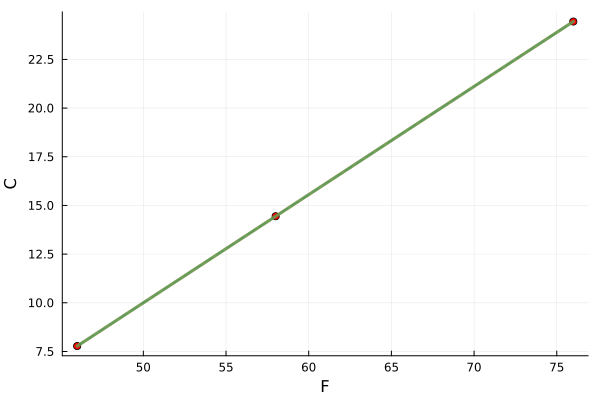

In [41]:
begin
    m = cov(x,y)/var(x)
    b = mean(y) - m*mean(x)
    (b=b, m=m)
end
nt = (first=1, next=2, last=3.1)
plot!(x -> m*x+b, lw=3, alpha = 0.7)

In [45]:
using Optim
loss((b,m)) = sum((b+m*x[i] - y[i])^2 for i=1:n)
result = optimize(loss, [0.0,0.0])


 * Status: success

 * Candidate solution
    Final objective value:     8.614606e-09

 * Found with
    Algorithm:     Nelder-Mead

 * Convergence measures
    √(Σ(yᵢ-ȳ)²)/n ≤ 1.0e-08

 * Work counters
    Seconds run:   0  (vs limit Inf)
    Iterations:    59
    f(x) calls:    116


In [46]:
let 
    n = length(x)
    model = Model(Ipopt.Optimizer)

    @variable(model, b)
    @variable(model, m)
    @objective(model, Min, sum((b +m*x[i]-y[i])^2 for i in 1:n))

    optimize!(model)
    (b=value(b), m=value(m))
end

UndefVarError: UndefVarError: `Ipopt` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
begin
    ∇loss(b,m,i) = 2*(b+m*x[i]-y[i]) .* [1,x[i]]
    ∇loss(b,m) = sum(∇loss(b,m,i) for i=1:n)
end

#∇loss(.1,.3)
begin
    ([loss([.1+eps(), .3]);loss([.1, 3+eps()])] .- loss([.1, .3])) ./ eps()
    
end

2-element Vector{Float64}:
  15.266666666666662
 682.9333333333332

In [53]:
using ForwardDiff
∇loss(.1,.3)
ForwardDiff.gradient(loss, [.1,.3])


2-element Vector{Float64}:
  15.266666666666662
 682.9333333333332

In [ ]:
let
	b, m = 0, 0  # starting guess
	
	for i=1:25
		db, dm = ∇loss(b,m)
		η = sum( (b+m*x[i]-y[i])*(db+dm*x[i]) for i=1:n)/sum( (db+dm*x[i])^2 for i=1:n)
		
		b, m  = (b, m) .- η .* (db, dm)
	end
	(b=b, m=m)
	
end